In [1]:
import os
import pathlib
import sys
import time
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import skimage
import tifffile
import tomli
import torch
from image_analysis_3D.featurization_utils.chammi75_featurization import (
    PerImageNormalize,
    SaturationNoiseInjector,
    call_chammi75_featurization_pipeline,
    featurize_2D_image_w_chammi75,
    get_chammi75_model,
)
from image_analysis_3D.featurization_utils.feature_writing_utils import (
    format_morphology_feature_name,
    save_features_as_parquet,
)
from image_analysis_3D.featurization_utils.loading_classes import (
    ImageSetLoader,
    ObjectLoader,
)
from image_analysis_3D.featurization_utils.resource_profiling_util import (
    start_profiling,
    stop_profiling,
)
from image_analysis_3D.featurization_utils.sammed3d_featurizer import (
    MicroscopySAMMed3DPipeline,
    call_whole_image_sammed3d_pipeline,
)
from image_analysis_3D.file_utils.arg_parsing_utils import (
    check_for_missing_args,
    parse_args,
)
from image_analysis_3D.file_utils.notebook_init_utils import (
    bandicoot_check,
    init_notebook,
)
from image_analysis_3D.image_utils.image_utils import (
    check_for_xy_squareness,
    crop_3D_image,
    expand_box,
    new_crop_border,
    select_objects_from_label,
    single_3D_image_expand_bbox,
    square_off_xy_crop_bbox,
)

root_dir, in_notebook = init_notebook()
image_base_dir = bandicoot_check(
    pathlib.Path(os.path.expanduser("~/mnt/bandicoot")).resolve(), root_dir
)

if in_notebook:
    import tqdm.notebook as tqdm
else:
    import tqdm

In [2]:
# Download SAM3D checkpoint
sam3dmed_checkpoint_url = (
    "https://huggingface.co/blueyo0/SAM-Med3D/resolve/main/sam_med3d_turbo.pth"
)
sam3dmed_checkpoint_path = pathlib.Path("../models/sam-med3d-turbo.pth").resolve()
if not sam3dmed_checkpoint_path.exists():
    sam3dmed_checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(sam3dmed_checkpoint_url, str(sam3dmed_checkpoint_path))
extractor = MicroscopySAMMed3DPipeline(
    sammed3d_path=str(sam3dmed_checkpoint_path),
    device="cuda" if torch.cuda.is_available() else "cpu",
)
device = "cuda" if torch.cuda.is_available() else "cpu"
chammi75_model = get_chammi75_model(device)

In [3]:
if not in_notebook:
    arguments_dict = parse_args()
    patient = arguments_dict["patient"]
    well_fov = arguments_dict["well_fov"]
    channel = arguments_dict["channel"]
    compartment = arguments_dict["compartment"]
    processor_type = arguments_dict["processor_type"]
    input_subparent_name = arguments_dict["input_subparent_name"]
    mask_subparent_name = arguments_dict["mask_subparent_name"]
    output_features_subparent_name = arguments_dict["output_features_subparent_name"]

else:
    well_fov = "D5-2"
    patient = "NF0014_T1"
    channel = "DNA"
    compartment = "Nuclei"
    processor_type = "GPU"
    input_subparent_name = "zstack_images"
    mask_subparent_name = "segmentation_masks"
    output_features_subparent_name = "extracted_features"

image_set_path = pathlib.Path(
    f"{image_base_dir}/data/{patient}/{input_subparent_name}/{well_fov}/"
)
mask_set_path = pathlib.Path(
    f"{image_base_dir}/data/{patient}/{mask_subparent_name}/{well_fov}/"
)
output_parent_path = pathlib.Path(
    f"{image_base_dir}/data/{patient}/{output_features_subparent_name}/{well_fov}/"
)
output_parent_path.mkdir(parents=True, exist_ok=True)
channel_mapping_file_path = pathlib.Path(
    f"{root_dir}/config/channel_mapping.toml"
).resolve(strict=True)

# given this is nucleocentric, we will hardcode the compartment to be nuclei for now
# the feature name will read nucleocentric
# the compartment to read in will be nuclei however.
compartment = "Nuclei"

In [4]:
# read in channel mapping
with open(channel_mapping_file_path, "rb") as f:
    channel_mapping_dict = tomli.load(f)
channel_n_compartment_mapping = channel_mapping_dict["channel_mapping"]

In [5]:
start_time, start_mem = start_profiling()

In [6]:
image_set_loader = ImageSetLoader(
    image_set_path=image_set_path,
    mask_set_path=mask_set_path,
    anisotropy_spacing=(1, 0.1, 0.1),
    channel_mapping=channel_n_compartment_mapping,
    image_set_name=well_fov,
    mask_key_name=[channel_n_compartment_mapping[compartment]],
    raw_image_key_name=[channel_n_compartment_mapping[channel]],
)

In [7]:
object_loader = ObjectLoader(
    image_set_loader.image_set_dict[channel],
    image_set_loader.image_set_dict[compartment],
    channel,
    compartment,
)

In [8]:
label_ids = np.unique(object_loader.label_image)
label_ids = label_ids[label_ids != 0]

In [15]:
list_of_feature_dicts = []
for label in tqdm.tqdm(label_ids, desc="Extracting features for objects"):
    # get the label image for the current label
    label_image = select_objects_from_label(object_loader.label_image, [label])
    # get the bbox for the current label
    props_image = skimage.measure.regionprops_table(label_image, properties=["bbox"])
    bbox_image = (
        props_image["bbox-0"][0],  # z min
        props_image["bbox-1"][0],  # y min
        props_image["bbox-2"][0],  # x min
        props_image["bbox-3"][0],  # z max
        props_image["bbox-4"][0],  # y max
        props_image["bbox-5"][0],  # x max
    )
    # get the new bbox expanded by n
    new_bbox = single_3D_image_expand_bbox(
        image=label_image, bbox=bbox_image, expand_pixels=25, anisotropy_factor=10
    )
    # make the bbox square in xy
    new_bbox = square_off_xy_crop_bbox(bbox=new_bbox)
    if not check_for_xy_squareness(bbox=new_bbox):
        print(f"Warning: bbox is not square in xy after expansion of 25 pixels")
    # crop the image
    cropped_image = crop_3D_image(object_loader.image, new_bbox)
    # z max project the image
    z_max_proj_image = cropped_image.max(axis=0)

    # extract SAMMed3D features for the cropped image
    sammed3d_output_dict = call_whole_image_sammed3d_pipeline(
        image=cropped_image,
        feature_type="cls",
        extractor=extractor,
    )
    chammi75_features = call_chammi75_featurization_pipeline(
        cropped_image=z_max_proj_image, model=chammi75_model
    )
    # make a new dictionary to hold all features
    combined_feature_dict = {
        "feature_name": [],
        "feature_value": [],
        "object_id": [],
        "image_set": [],
    }
    for i, feat_value in enumerate(sammed3d_output_dict["value"]):
        combined_feature_dict["feature_name"].append(
            format_morphology_feature_name(
                compartment="Nucleocentric",
                channel=channel,
                feature_type="SAMMed3D",
                measurement=f"Feature{i}",
            )
        )
        combined_feature_dict["feature_value"].append(feat_value)
        combined_feature_dict["object_id"].append(label)
        combined_feature_dict["image_set"].append(well_fov)
    for i, feat_value in enumerate(chammi75_features[0]):
        print(feat_value)
        combined_feature_dict["feature_name"].append(
            format_morphology_feature_name(
                compartment="Nucleocentric",
                channel=channel,
                feature_type="CHAMMI75",
                measurement=f"Feature{i}",
            )
        )
        combined_feature_dict["feature_value"].append(feat_value.item())
        combined_feature_dict["object_id"].append(label)
        combined_feature_dict["image_set"].append(well_fov)
    df = pd.DataFrame(combined_feature_dict)
    list_of_feature_dicts.append(df)


final_df = pd.concat(list_of_feature_dicts, ignore_index=True)
# pivot the df such that the feature names are the columns and the feature values are the values, with object label as an id variable
final_df = final_df.pivot(
    index=["object_id", "image_set"], columns="feature_name", values="feature_value"
).reset_index()
# remove the labeld name of the index
final_df.columns.name = None
final_df.head()

Extracting features for objects:   0%|          | 0/18 [00:00<?, ?it/s]

,object_id,image_set,Nucleocentric_DNA_CHAMMI75_Feature0,Nucleocentric_DNA_CHAMMI75_Feature1,Nucleocentric_DNA_CHAMMI75_Feature10,Nucleocentric_DNA_CHAMMI75_Feature100,Nucleocentric_DNA_CHAMMI75_Feature101,Nucleocentric_DNA_CHAMMI75_Feature102,Nucleocentric_DNA_CHAMMI75_Feature103,Nucleocentric_DNA_CHAMMI75_Feature104,...,Nucleocentric_DNA_SAMMed3D_Feature90,Nucleocentric_DNA_SAMMed3D_Feature91,Nucleocentric_DNA_SAMMed3D_Feature92,Nucleocentric_DNA_SAMMed3D_Feature93,Nucleocentric_DNA_SAMMed3D_Feature94,Nucleocentric_DNA_SAMMed3D_Feature95,Nucleocentric_DNA_SAMMed3D_Feature96,Nucleocentric_DNA_SAMMed3D_Feature97,Nucleocentric_DNA_SAMMed3D_Feature98,Nucleocentric_DNA_SAMMed3D_Feature99
0,514,D5-2,7.867586,-2.322820,0.029014,0.118224,2.821245,-1.182603,-3.824584,2.742022,...,-0.006128,-0.095677,0.031794,-0.010561,0.029794,0.044137,0.020700,0.216427,0.293932,0.240144
1,771,D5-2,-4.518426,-1.823785,2.157801,-0.580074,-2.582984,-0.321649,2.252282,-0.003391,...,-0.005672,-0.108603,0.074770,-0.011206,0.027105,-0.059631,0.041441,0.209003,0.291271,0.090920
2,2313,D5-2,5.660724,-4.278221,4.401998,3.608307,0.407991,2.820103,-2.946132,2.896868,...,-0.005989,-0.030645,0.076047,-0.010760,0.036911,0.036232,0.021512,0.236949,0.306045,0.263332
3,2570,D5-2,0.390315,-3.204708,2.774297,-1.394218,-2.218767,-0.799362,3.611105,0.759419,...,-0.005624,-0.076745,0.103866,-0.010599,0.025692,-0.003265,0.057735,0.247264,0.278665,0.282111
4,2827,D5-2,0.158037,-5.285744,5.200577,1.573798,0.166226,2.896841,-3.270519,2.983973,...,-0.005704,-0.115987,0.004481,-0.011109,0.030950,0.023629,0.029067,0.211681,0.397502,0.180548


In [ ]:
# split between SAMMed3D and CHAMMI75 features in the column names
sammed3d_feature_cols = [col for col in final_df.columns if "SAMMed3D" in col]
chammi75_feature_cols = [col for col in final_df.columns if "CHAMMI75" in col]
sammed_3d_df = final_df[["object_id", "image_set"] + sammed3d_feature_cols]
chammi75_df = final_df[["object_id", "image_set"] + chammi75_feature_cols]
# save the features as parquet files
save_path = save_features_as_parquet(
    parent_path=output_parent_path,
    df=final_df,
    feature_type="SAMMed3D",
    channel=channel,
    compartment="Nucleocentric",
    cpu_or_gpu=processor_type,
)
save_path = save_features_as_parquet(
    parent_path=output_parent_path,
    df=chammi75_df,
    feature_type="CHAMMI75",
    channel=channel,
    compartment="Nucleocentric",
    cpu_or_gpu=processor_type,
)

In [11]:
stop_profiling(
    start_time=start_time,
    start_mem=start_mem,
    feature_type="Nucleocentric",
    well_fov=well_fov,
    patient_id=patient,
    channel=channel,
    compartment=compartment,
    CPU_GPU=processor_type,
    output_file_dir=pathlib.Path(
        f"{root_dir}/data/{patient}/extracted_features/run_stats/{well_fov}_{channel}_{compartment}_Nucleocentric_{processor_type}.parquet"
    ),
)

True

In [12]:
if in_notebook:
    # load the first label image to get the metadata for saving the features as a tiff
    label = label_ids[0]
    label_image = select_objects_from_label(object_loader.label_image, [label])

/tmp/ipykernel_2550193/906120939.py:33: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.imshow(cropped_image.max(axis=0))


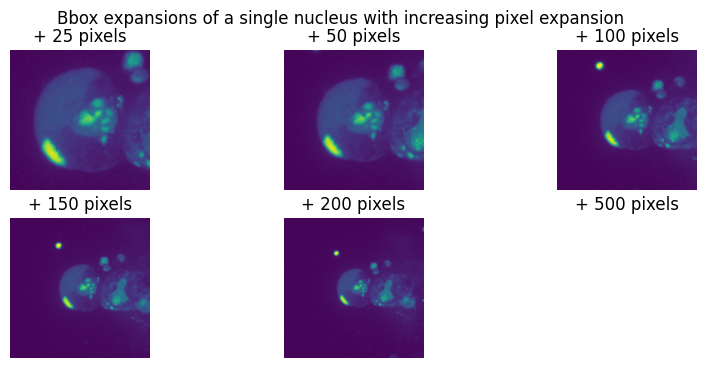

In [13]:
if in_notebook:
    expand_pixels_by_list = [25, 50, 100, 150, 200, 500]
    plt.figure(figsize=(10, 4))

    for index, expand_pixel_by in enumerate(expand_pixels_by_list):
        # get the inital nuclei bbox
        props_image = skimage.measure.regionprops_table(
            label_image, properties=["bbox"]
        )
        bbox_image = (
            props_image["bbox-0"][0],  # z min
            props_image["bbox-1"][0],  # y min
            props_image["bbox-2"][0],  # x min
            props_image["bbox-3"][0],  # z max
            props_image["bbox-4"][0],  # y max
            props_image["bbox-5"][0],  # x max
        )
        # get the new bbox expanded by n
        new_bbox = single_3D_image_expand_bbox(
            image=label_image,
            bbox=bbox_image,
            expand_pixels=expand_pixel_by,
            anisotropy_factor=10,
        )
        new_bbox = square_off_xy_crop_bbox(bbox=new_bbox)
        if not check_for_xy_squareness(bbox=new_bbox):
            print(
                f"Warning: bbox is not square in xy after expansion of {expand_pixel_by} pixels"
            )
        # crop the image
        cropped_image = crop_3D_image(object_loader.image, new_bbox)
        plt.subplot(2, 3, index + 1)
        plt.imshow(cropped_image.max(axis=0))
        plt.title(f"+ {expand_pixel_by} pixels")
        plt.axis("off")
    plt.suptitle(f"Bbox expansions of a single nucleus with increasing pixel expansion")
    plt.show()

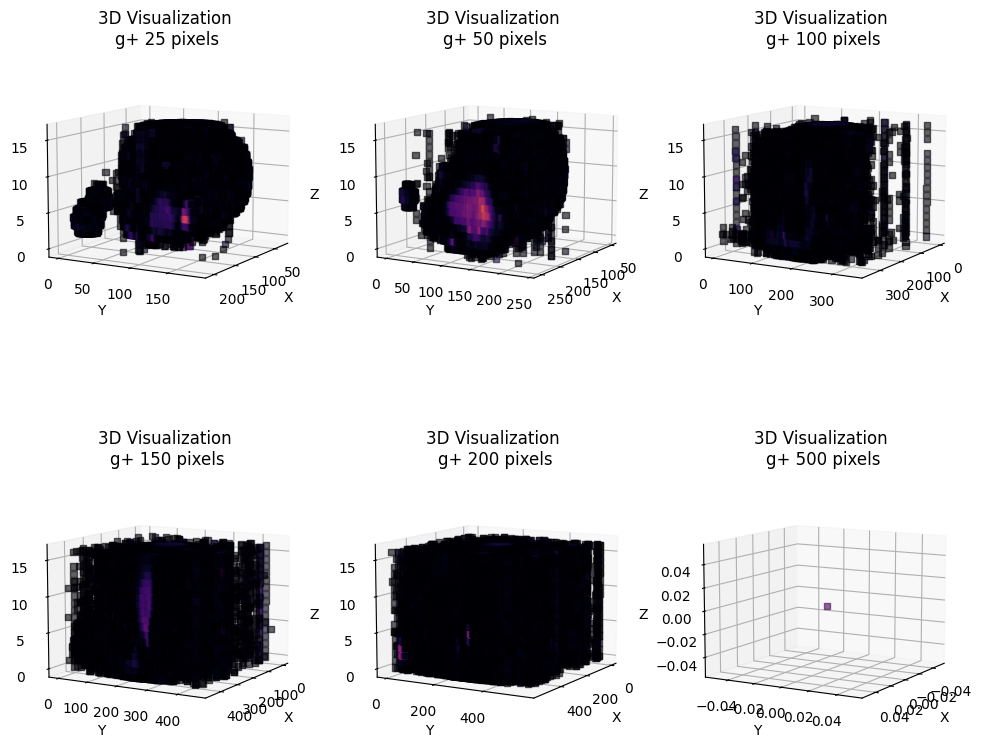

In [14]:
if in_notebook:
    fig = plt.figure(figsize=(12, 10))

    for index, expand_pixel_by in enumerate(expand_pixels_by_list):
        # get the inital nuclei bbox
        props_image = skimage.measure.regionprops_table(
            label_image, properties=["bbox"]
        )
        bbox_image = (
            props_image["bbox-0"][0],  # z min
            props_image["bbox-1"][0],  # y min
            props_image["bbox-2"][0],  # x min
            props_image["bbox-3"][0],  # z max
            props_image["bbox-4"][0],  # y max
            props_image["bbox-5"][0],  # x max
        )
        # get the new bbox expanded by n
        new_bbox = single_3D_image_expand_bbox(
            image=label_image,
            bbox=bbox_image,
            expand_pixels=expand_pixel_by,
            anisotropy_factor=10,
        )
        new_bbox = square_off_xy_crop_bbox(bbox=new_bbox)
        if not check_for_xy_squareness(bbox=new_bbox):
            print(
                f"Warning: bbox is not square in xy after expansion of {expand_pixel_by} pixels"
            )
        # crop the image
        cropped_image = crop_3D_image(object_loader.image, new_bbox)
        # visualize the 3D cropped image in 3D space

        ax = fig.add_subplot(2, 3, index + 1, projection="3d")
        try:
            # Create a threshold to show only significant intensity values
            threshold = np.percentile(
                cropped_image, 85
            )  # Show pixels above nth percentile
            mask = cropped_image > threshold

            # Get coordinates of voxels above threshold
            z, y, x = np.where(mask)
            intensities = cropped_image[mask]

            # Normalize intensities for color mapping
            norm_intensities = (intensities - intensities.min()) / (
                intensities.max() - intensities.min()
            )

            # Create 3D scatter plot
            scatter = ax.scatter(
                x, y, z, c=norm_intensities, cmap="inferno", marker="s", s=20, alpha=0.6
            )
        except:
            # failed to grab the image
            # proceed to plotting a blank image C:
            scatter = ax.scatter(
                [0], [0], [0], c=[0], cmap="viridis", marker="s", s=20, alpha=0.6
            )

        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        ax.set_title(f"3D Visualization \ng+ {expand_pixel_by} pixels")
        ax.view_init(elev=10, azim=30)
    plt.show()